# Logistic Regression from Scratch

## 1. Data Preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:

# Define features: column 0 is Age, column 1 is Ticket Price
X = np.array([
    [10 , 3 ],
    [20 , 5 ],
    [35, 20],
    [50, 10],
])

# Define target labels: 0 (did not survive), 1 (survived)
y = np.array([0, 0, 1, 1])

## 2. The Sigmoid Function

In [3]:
def sigmoid(z):
  """
  Computes the sigmoid of z.
  Args:
      z: A scalar or numpy array of any size.
  Returns:
      s: sigmoid(z)
  """
  return 1 / (1 + np.exp(-z))

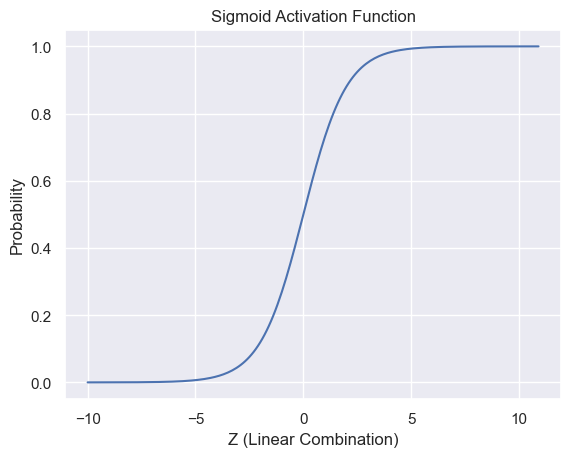

In [4]:
# Create an array of values from -10 to 10 to visualize the S-curve
z = np.arange(-10, 11, 0.1)
sigmoid_values = sigmoid(z)

# Plot the sigmoid function
plt.plot(z, sigmoid_values)
plt.title("Sigmoid Activation Function")
plt.xlabel("Z (Linear Combination)")
plt.ylabel("Probability")
plt.grid(True)

## 3. Making Predictions

In [5]:
# Initialize weights (W) and bias (b) with arbitrary small values to test the prediction logic
w_init = np.array([0.5, -2])
b_init = 0.01

In [6]:
def make_prediction(X, W, b, threshold=0.5):
  """
  Calculates the model output for each example in X.
  """
  m = X.shape[0]
  prob_list = np.zeros((m,))

  for i in range(m):
    # Calculate z = w1*x1 + w2*x2 + ... + b
    z = np.dot(W, X[i]) + b
    # Convert z into a probability
    prob_list[i] = sigmoid(z)

  # If probability > threshold, return True (1), else False (0)
  prediction = (prob_list > threshold)
  return prediction

# Test with initial weights
print("Initial Predictions:", make_prediction(X, w_init, b_init))

Initial Predictions: [False  True False  True]


## 4. Cost Function

In [7]:
def compute_cost(X, y, W, b):
  """
  Computes the Binary Cross-Entropy Cost.
  """
  m = X.shape[0]
  total_cost = 0.0

  for i in range(m):
    z = np.dot(W, X[i]) + b
    prob = sigmoid(z)
    # Log Loss formula: -[y*log(p) + (1-y)*log(1-p)]
    # We sum the inner part here and negate later
    total_cost += (y[i] * np.log(prob)) + ((1 - y[i]) * np.log(1 - prob))

  # Average the cost and negate
  return total_cost / (-m)

print(f"Initial Cost: {compute_cost(X, y, w_init, b_init):.4f}")

Initial Cost: 5.8777


## 5. Gradient Computation

In [8]:
def calculate_gradient(X, y, W, b):
  """
  Computes the partial derivatives of the cost w.r.t parameters.
  """
  m, n = X.shape
  dj_dw = np.zeros((n,))
  dj_db = 0.0

  for i in range(m):
    z = np.dot(W, X[i]) + b
    prob = sigmoid(z)
    # Difference between prediction and actual label
    error = prob - y[i]

    # Gradient for bias
    dj_db += error

    # Gradient for each weight
    for j in range(n):
      dj_dw[j] += error * X[i, j]

  # Return average gradients
  return dj_dw / m, dj_db / m

## 6. Gradient Descent

In [9]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
  """
  Optimizes W and b by moving in the direction of steepest descent.
  """
  w = w_input
  b = b_input
  cost_history = []

  for i in range(max_iter):
    # Step 1: Compute gradients
    dj_dw, dj_db = calculate_gradient(X, y, w, b)

    # Step 2: Update parameters (w = w - learning_rate * gradient)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    # Step 3: Record the cost to monitor convergence
    if i % 100 == 0:
      cost = compute_cost(X, y, w, b)
      cost_history.append(cost)
      print(f"Iter {i}: Cost {cost:.4f}")

  return w, b, cost_history

In [10]:
# Get number of features from X
n = X.shape[1]

# Reset W and b to zeros for a clean training start
W_init = np.zeros((n,))
b_init = 0.0

# Run Gradient Descent: find optimal weights and bias
# We use a large number of iterations (100,000) and a small learning rate (0.01)
w_final, b_final, cost_history = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01)

Iter 0: Cost 0.7342
Iter 100: Cost 0.5275
Iter 200: Cost 0.4928
Iter 300: Cost 0.4614
Iter 400: Cost 0.4330
Iter 500: Cost 0.4073
Iter 600: Cost 0.3840
Iter 700: Cost 0.3629
Iter 800: Cost 0.3436
Iter 900: Cost 0.3260
Iter 1000: Cost 0.3099
Iter 1100: Cost 0.2952
Iter 1200: Cost 0.2817
Iter 1300: Cost 0.2693
Iter 1400: Cost 0.2578
Iter 1500: Cost 0.2472
Iter 1600: Cost 0.2374
Iter 1700: Cost 0.2283
Iter 1800: Cost 0.2198
Iter 1900: Cost 0.2119
Iter 2000: Cost 0.2045
Iter 2100: Cost 0.1976
Iter 2200: Cost 0.1911
Iter 2300: Cost 0.1851
Iter 2400: Cost 0.1794
Iter 2500: Cost 0.1740
Iter 2600: Cost 0.1689
Iter 2700: Cost 0.1641
Iter 2800: Cost 0.1596
Iter 2900: Cost 0.1553
Iter 3000: Cost 0.1512
Iter 3100: Cost 0.1473
Iter 3200: Cost 0.1436
Iter 3300: Cost 0.1401
Iter 3400: Cost 0.1368
Iter 3500: Cost 0.1336
Iter 3600: Cost 0.1305
Iter 3700: Cost 0.1276
Iter 3800: Cost 0.1248
Iter 3900: Cost 0.1222
Iter 4000: Cost 0.1196
Iter 4100: Cost 0.1172
Iter 4200: Cost 0.1148
Iter 4300: Cost 0.1126


In [11]:
# Display the optimized parameters found by the algorithm
print("Final Weights (W):", w_final)
print("Final Bias (b):", b_final)

Final Weights (W): [0.22918287 0.49060656]
Final Bias (b): -11.172459126367531


In [12]:
# Generate final predictions using the trained parameters
# .astype(int) converts True/False to 1/0 for easier comparison with original 'y'
prediction = make_prediction(X, w_final, b_final).astype(int)

print("Final Model Predictions:", prediction)
print("Actual Target Labels:   ", y)

Final Model Predictions: [0 0 1 1]
Actual Target Labels:    [0 0 1 1]
